# 📘 S4_P1 — KNN en RÉGRESSION : prédire les ventes avec les voisins

## 🎯 Ce que tu vas apprendre
1. Adapter KNN à la **régression** : prédire un nombre = la moyenne des k voisins
2. Chercher le meilleur k en **minimisant la RMSE** (et non maximiser l'accuracy)
3. Lire la courbe RMSE-vs-k (la « vallée » du compromis biais-variance)
4. Déjouer deux pièges de lecture pandas : `df.min()` et `df.idxmin()`

## 📖 Rappel du dataset « Advertising » (déjà vu en S2_P3)
200 campagnes : budgets **TV / radio / journaux** (milliers de $) → **ventes** (milliers d'unités). En S2_P3, une régression LINÉAIRE prédisait les ventes. Ici, on remplace la droite par… les voisins.

---
Imports + chargement du CSV.

In [67]:
import pandas as pd
import numpy as np

adv_df = pd.read_csv("Advertising.csv")

Aperçu : 200 lignes × 4 colonnes, tout est numérique et propre.

In [68]:
adv_df

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,9.7
197,177.0,9.3,6.4,12.8
198,283.6,42.0,66.2,25.5


Import de `train_test_split` (cf. S2_P3 pour le détail).

In [69]:
from sklearn.model_selection import train_test_split

Split 80/20 (`random_state=32`) : 160 campagnes de train, 40 de test.

In [70]:
train_data, test_data = train_test_split(adv_df, test_size=0.2,random_state=32)

Aperçu du test (40 campagnes).

In [71]:
test_data

,TV,radio,newspaper,sales
122,224.0,2.4,15.6,11.6
186,139.5,2.1,26.6,10.3
167,206.8,5.2,19.4,12.2
101,296.4,36.3,100.9,23.8
29,70.6,16.0,40.8,10.5
75,16.9,43.7,89.4,8.7
144,96.2,14.8,38.9,11.4
28,248.8,27.1,22.9,18.9
121,18.8,21.7,50.4,7.0
182,56.2,5.7,29.7,8.7


Aperçu du train (160 campagnes).

In [72]:
train_data

,TV,radio,newspaper,sales
156,93.9,43.5,50.5,15.3
154,187.8,21.1,9.5,15.6
153,171.3,39.7,37.7,19.0
197,177.0,9.3,6.4,12.8
185,205.0,45.1,19.6,22.6
...,...,...,...,...
190,39.5,41.1,5.8,10.8
124,229.5,32.3,74.2,19.7
54,262.7,28.8,15.9,20.2
133,219.8,33.5,45.1,19.6


Séparation X (TV, radio, newspaper) / y (sales) pour le train et le test — méthode `drop("sales", axis=1)`.

In [73]:
X_train = train_data.drop("sales",axis = 1)
y_train = train_data["sales"]
X_test = test_data.drop("sales", axis = 1)
y_test = test_data["sales"]

## Étape 1 — Les outils : KNN version RÉGRESSION

**Ce que fait le code :**
- La ligne `#from sklearn.linear_model import LinearRegression` est **commentée** : c'est la trace du modèle précédent (S2_P3) — on le remplace aujourd'hui.
- `KNeighborsRegressor` → le KNN pour prédire des **nombres** (≠ `KNeighborsClassifier` qui prédit des classes).
- `root_mean_squared_error` → la RMSE directe.

In [74]:
#from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import root_mean_squared_error

## Étape 2 — Créer le modèle

### 🧠 THÉORIE — KNN en régression : la moyenne des voisins

Tu connais le KNN **classifieur** (S3_P3) : vote majoritaire des k voisins. La version **régression** change une seule chose — au lieu de voter, on fait la **MOYENNE** :

$$\hat{y} = \frac{1}{k}\sum_{i \,\in\, k\text{ voisins}} y_i$$

**Concrètement ici, avec `n_neighbors=5` :** pour prédire les ventes d'une nouvelle campagne, le modèle :
1. cherche les **5 campagnes du train les plus proches** (distance euclidienne sur les 3 budgets),
2. prend leurs 5 chiffres de ventes réels,
3. renvoie leur **moyenne**. C'est tout !

**Deux propriétés à comprendre :**
- La prédiction est forcément **dans la gamme des valeurs du train** (une moyenne ne peut pas extrapoler au-delà) — contrairement à une droite qui extrapole à l'infini.
- ⚠️ Toujours le talon d'Achille des KNN : les **échelles**. `TV` va jusqu'à ~300, `radio`/`newspaper` jusqu'à ~50-110 → TV domine le calcul de distance. Standardiser aiderait (non fait ici).

💡 Le nom de variable `MLR` (Multiple Linear Regression) est un vestige de S2_P3 — c'est maintenant un KNN ! Les noms de variables mentent parfois : fie-toi au code.

In [75]:
#MLR = LinearRegression()
MLR = KNeighborsRegressor(n_neighbors=5)

## Étape 3 — Entraînement (enfin… mémorisation !)

`MLR.fit(X_train, y_train)` — ✅ sur le TRAIN, correctement (le bug de S2_P3 n'a pas été reproduit !). Rappel : pour un KNN, `fit` ne calcule rien — il **stocke** simplement les 160 campagnes, qui serviront de base de comparaison à chaque prédiction.

In [76]:
#fit the data
#Predict the y_test 
#Use RootMeanSquaredError 
MLR.fit(X_train,y_train)



,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


Prédiction sur les 40 campagnes de test : pour chacune, moyenne des ventes de ses 5 voisines du train.

In [77]:
y_pred = MLR.predict(X_test)

## Étape 4 — Première RMSE

**RMSE ≈ 1.347** (milliers d'unités) avec k=5. Pour référence : la régression linéaire de S2_P3 (une fois corrigée de son bug) donne ~1.9-2.0 sur le même split — le KNN fait donc mieux ici !

💡 L'ordre `root_mean_squared_error(y_pred, y_test)` est inversé par rapport à la convention `(y_true, y_pred)` mais **sans conséquence** pour la RMSE (elle est symétrique : $(a-b)^2=(b-a)^2$). Réflexe à garder quand même : la convention, toujours.

In [78]:
root_mean_squared_error(y_pred,y_test)

1.3473863588444117

## Étape 5 — Chercher le meilleur k : la boucle

**Ce que fait le code, pas à pas :**
1. Deux listes vides (`rmse`, `list_k`),
2. Pour chaque k de 1 à 49 : nouveau KNN à k voisins → fit → predict → RMSE sur le test → empiler les résultats.

**Ce qu'on cherche cette fois : le MINIMUM.** En classification on maximisait l'accuracy ; en régression on **minimise l'erreur**. Le raisonnement biais-variance reste identique :
- **k=1** : la prédiction copie UNE campagne → très sensible au bruit (surapprentissage),
- **k=49** : moyenne sur un tiers du train → prédictions trop lissées, presque toutes identiques (sous-apprentissage),
- le meilleur k = le creux de la courbe.

In [79]:
rmse = []
list_k = []
for k in range(1,50,1):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    list_k.append(k)
    rmse.append(root_mean_squared_error(y_test, y_pred))


## 📊 Étape 6 — La courbe RMSE vs k

**Axes :** X = k (nombre de voisins), Y = RMSE sur le test.

**🔍 Comment lire cette courbe, étape par étape :**
1. **À gauche (k=1-2)** : RMSE un peu élevée — le modèle colle trop à des campagnes individuelles (bruit).
2. **Le creux (vers k=3)** : le point le plus BAS = le meilleur compromis. C'est LE k à retenir.
3. **À droite (k grandit)** : la RMSE **remonte régulièrement** — en moyennant trop de voisins, les prédictions convergent vers la moyenne globale des ventes et perdent toute finesse. À k=49, le modèle est presque aussi bête que « prédire toujours la moyenne ».

**La forme en “vallée” (descente–creux–remontée) est LA signature visuelle du compromis biais-variance** — tu la reverras dans toute ta vie de data scientist.

<Axes: xlabel='K'>

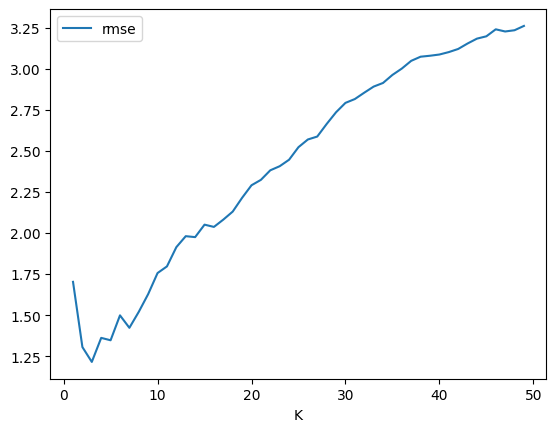

In [80]:
df = pd.DataFrame({"K":list_k,"rmse":rmse})
df.plot(x = "K",y = "rmse")


## Étape 7 — Lire le minimum… avec précaution

**Ce que fait le code :** `df.min()` renvoie le minimum **de chaque colonne, indépendamment** :
- `K → 1.0` : la plus petite valeur de k testée — aucun rapport avec la performance ! (piège de lecture)
- `rmse → 1.2156` : la **meilleure RMSE** obtenue, tous k confondus. ✅

⚠️ Ce tableau ne dit PAS « le meilleur k est 1 » ! Il dit juste « la colonne K commence à 1 » et « la meilleure erreur vaut 1.2156 ». Pour savoir QUEL k donne cette erreur → cellule suivante.

In [81]:
df.min()

K       1.000000
rmse    1.215627
dtype: float64

## 🔍 Étape 8 — `idxmin()` : le piège de l'indice de ligne

**Ce que fait le code :** `df.idxmin()` renvoie, pour chaque colonne, **l'INDICE DE LIGNE** où se trouve le minimum (pas la valeur de k !).

**Décodons le résultat :**
- `K → 0` : le minimum de la colonne K (qui vaut 1) est à la ligne 0. Trivial, à ignorer.
- `rmse → 2` : la meilleure RMSE est à la **ligne d'indice 2**. Or `list_k = [1, 2, 3, ...]` → ligne 0 = k=1, ligne 1 = k=2, **ligne 2 = k=3** !

**👉 Le meilleur k est donc 3** (et non 2 — l'indice de ligne et la valeur de k sont décalés de 1 !).

**⭐ La bonne façon d'écrire ça, sans ambiguïté :**
```python
df.loc[df["rmse"].idxmin(), "K"]   # → 3 : la valeur de K à la ligne du minimum
```

## 📝 Résumé du notebook
1. **KNN régression** = moyenne des y des k voisins (vs vote en classification).
2. La courbe RMSE-vs-k a une forme de **vallée** : creux = meilleur k (ici k=3, RMSE 1.216).
3. `df.min()` = minimum par colonne (indépendants !) ; `df.idxmin()` = INDICE du minimum, pas la valeur de K.
4. Le KNN (1.22) bat ici la régression linéaire de S2_P3 — aucune famille de modèle n'est toujours la meilleure : il faut comparer.

In [82]:
df.idxmin()

K       0
rmse    2
dtype: int64